# Approach to a solution

This file contains one way of approaching the exercise. Note that especially in the analysis part, you can of course add much more stats or visualizations of your choosing. So this by no means is the one-and-only solution....

And of course, there are many more (and potentially better) analyses you could make...

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 0. Load and Inspect Raw and Cleaned Data

In [2]:
# Load the raw and cleaned data
df_raw = pd.read_csv("wozwaarde.csv", encoding='utf-8', sep=';')
df_clean = pd.read_csv("wozwaarde-clean.csv", encoding='utf-8')

# Inspect raw dataset
print("RAW DATA HEAD:")
print(df_raw.head())
print("\nRAW DATA INFO:")
print(df_raw.info())

# Inspect cleaned dataset
print("\nCLEANED DATA HEAD:")
print(df_clean.head())
print("\nCLEANED DATA INFO:")
print(df_clean.info())


RAW DATA HEAD:
                          wijk      2014      2015      2016      2017  \
0    A00 Burgwallen-Oude Zijde  263417.0  273525.0  289984.0  339548.0   
1  A01 Burgwallen-Nieuwe Zijde  267895.0  281193.0  296762.0  351214.0   
2      A02 Grachtengordel-West  490251.0  502230.0  560841.0  674610.0   
3      A03 Grachtengordel-Zuid  469946.0  478371.0  531225.0  627625.0   
4       A04 Nieuwmarkt/Lastage  295239.0  303500.0  340364.0  386716.0   

       2018  
0  400010.0  
1  391011.0  
2  755091.0  
3  697576.0  
4  438942.0  

RAW DATA INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   wijk    106 non-null    object 
 1   2014    101 non-null    float64
 2   2015    104 non-null    float64
 3   2016    104 non-null    float64
 4   2017    103 non-null    float64
 5   2018    104 non-null    float64
dtypes: float64(5), object(1)
memory usa

### Step 0: Understanding the Data

We start by loading both the raw and cleaned WOZ-waarde datasets. By inspecting the raw file (`wozwaarde.csv`), we observe:

- Inconsistent formatting in wijk or stadsdeel codes.
- Presence of unnecessary or mixed granularity rows.
- The data is in **wide format**, with years as column names.

The cleaned dataset (`wozwaarde-clean.csv`) removes these inconsistencies, standardizes codes, and ensures that each row contains a "wijk" (residential area) with a code and name, followed by yearly WOZ values.


# 1. Convert Wide Format to Long Format

### Step 1: Reshape Data (Wide to Long)

The cleaned data contains one column per year. To make it suitable for time series analysis and plotting, we reshape it using `pd.melt()`, which converts it into a long format — each row now represents a unique combination of wijk, year, and WOZ value.


In [3]:
df_long = pd.melt(
    df_clean,
    id_vars=['wijk', 'code', 'stadsdeel'],
    var_name="year",
    value_name="wozwaarde"
)

# Convert jaar column to int and WOZ-waarde to numeric
df_long["year"] = df_long["year"].astype(int)
df_long["wozwaarde"] = pd.to_numeric(df_long["wozwaarde"], errors='coerce')

# Display transformed data
df_long.head()


,wijk,code,stadsdeel,year,wozwaarde
0,Burgwallen-Oude Zijde,A00,Centrum,2014,263417.0
1,Burgwallen-Nieuwe Zijde,A01,Centrum,2014,267895.0
2,Grachtengordel-West,A02,Centrum,2014,490251.0
3,Grachtengordel-Zuid,A03,Centrum,2014,469946.0
4,Nieuwmarkt/Lastage,A04,Centrum,2014,295239.0


# 2. Merge with Population Data

### Step 2: Merge with Population Data (Per Stadsdeel)

We downloaded demographic data per stadsdeel from the Amsterdam Jaarboek. After cleaning and reshaping, we joined it with our WOZ dataset by matching each `wijknaam` to its corresponding `stadsdeel`.

This enables us to normalize values per capita or track demographic-driven patterns in housing prices.


In [4]:
df_pop = pd.read_excel("https://cms.onderzoek-en-statistiek.nl/uploads/2021_jaarboek_2112_28485510ff.xlsx",
                   skiprows=2,
                   skipfooter=2)
df_pop.drop([0,9], inplace=True)  # drop empty line and total
df_pop

,stadsdeel,2016,2017,2018,2019,2020,2021
1,A Centrum,86499.0,86422.0,86851.0,86862.0,87310.0,87083.0
2,B Westpoort,200.0,192.0,198.0,177.0,106.0,145.0
3,E West,143964.0,143842.0,144210.0,145908.0,147421.0,148030.0
4,F Nieuw-West,149397.0,151677.0,155781.0,157964.0,160124.0,159522.0
5,K Zuid,143258.0,144432.0,145548.0,145966.0,146291.0,145301.0
6,M Oost,132421.0,135767.0,137454.0,140300.0,142049.0,141453.0
7,N Noord,92917.0,94766.0,96275.0,97200.0,99238.0,100887.0
8,T Zuidoost,86057.0,87854.0,87999.0,88610.0,89841.0,90076.0


In [5]:
# Function to extract the last word from a string
# This can be useful for cases where a string contains multiple words
# and you want to get only the last part (e.g., extracting a name from a code).

def get_name(s):
    return s.split()[-1]

In [6]:
# now, let's apply the  function:
df_pop['stadsdeel'] = df_pop['stadsdeel'].apply(get_name)

In [7]:
# The previous command is equivalent to using a throwaway function (lambda function) that is defined on the spot
# instead of creating a named function first:
# df2['stadsdeel'] = df2['stadsdeel'].apply(lambda s: s.split()[-1])

In [8]:
# Melt to long format: one row per stadsdeel per year
df_pop_long = pd.melt(df_pop, 
                      id_vars=['stadsdeel'],
                      var_name='year',
                      value_name='populatie')

# Convert jaar to int
df_pop_long['year'] = df_pop_long['year'].astype(int)
df_pop_long.head()

,stadsdeel,year,populatie
0,Centrum,2016,86499.0
1,Westpoort,2016,200.0
2,West,2016,143964.0
3,Nieuw-West,2016,149397.0
4,Zuid,2016,143258.0


In [9]:
# Merge WOZ data (df_long) with population (df_pop_long) on stadsdeel and jaar
df_merged = pd.merge(df_long, df_pop_long, how='left', on=['stadsdeel', 'year'])
df_merged.head()

,wijk,code,stadsdeel,year,wozwaarde,populatie
0,Burgwallen-Oude Zijde,A00,Centrum,2014,263417.0,NaN
1,Burgwallen-Nieuwe Zijde,A01,Centrum,2014,267895.0,NaN
2,Grachtengordel-West,A02,Centrum,2014,490251.0,NaN
3,Grachtengordel-Zuid,A03,Centrum,2014,469946.0,NaN
4,Nieuwmarkt/Lastage,A04,Centrum,2014,295239.0,NaN


# Data Analysis & Visualization

### Step 4: Data Analysis and Visualization

We use grouping and descriptive statistics to understand the distribution and trends of WOZ values. We then plot the WOZ development for a few selected "wijken" to observe how real estate values changed over time.

This helps us answer questions like:
- Which areas saw the highest growth?
- Are certain areas consistently above/below average?



In [10]:
df_merged.describe()

,year,wozwaarde,populatie
count,490.000000,4.780000e+02,294.000000
mean,2016.000000,2.856571e+05,125153.030612
std,1.415659,1.369124e+05,28653.001531
min,2014.000000,7.813700e+04,192.000000
25%,2015.000000,1.914288e+05,94766.000000
50%,2016.000000,2.516580e+05,143258.000000
75%,2017.000000,3.329392e+05,144432.000000
max,2018.000000,1.003743e+06,155781.000000


In [11]:
df_merged.groupby('stadsdeel')['wozwaarde'].agg([np.mean, np.median])
# if you want to, you can also select before grouping,
# but then, you need to first keep the grouping variable of course:
# df.loc[:,['stadsdeel','wozwaarde']].groupby('stadsdeel').agg([np.mean, np.median])

,mean,median
stadsdeel,,
Centrum,391529.640000,352421.0
Nieuw-West,216362.563380,191464.0
Noord,241600.837838,208055.5
Oost,263990.485714,269004.0
West,285322.500000,266207.0
Westpoort,206946.500000,206946.5
Zuid,394134.291139,310248.0
Zuidoost,161416.062500,150385.0


<Axes: xlabel='stadsdeel'>

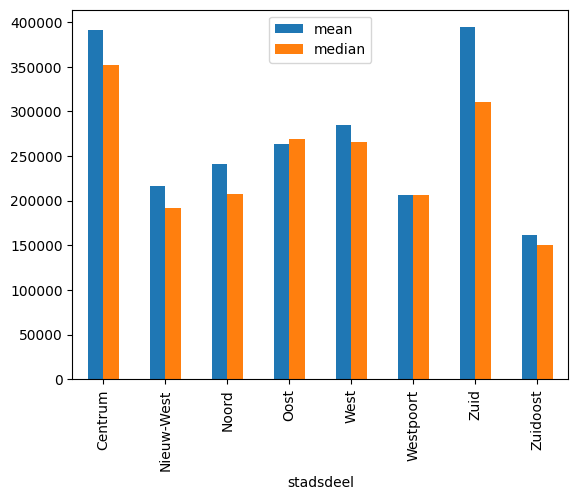

In [12]:
# given that we calculated the values anyway, we can also directy plot 
# them with matplotlib if we want to:
df_merged.groupby('stadsdeel')['wozwaarde'].agg([np.mean, np.median]).plot.bar()

<Axes: xlabel='stadsdeel', ylabel='wozwaarde'>

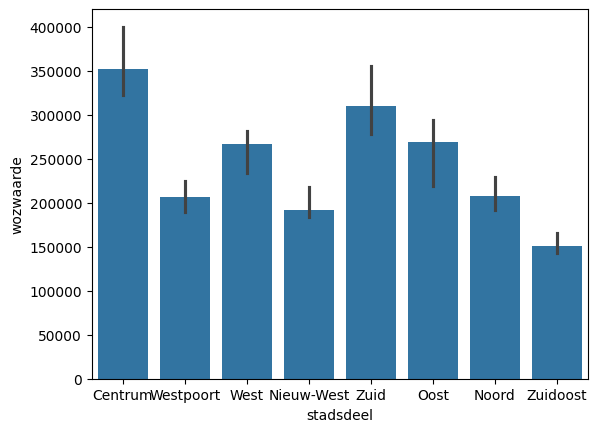

In [13]:
# alternative approach with seaborn:
sns.barplot(x='stadsdeel', y='wozwaarde', estimator=np.median, data=df_merged)

### Over-time developments and differences per 'stadsdeel' and/or per 'wijk'

<Axes: xlabel='year', ylabel='wozwaarde'>

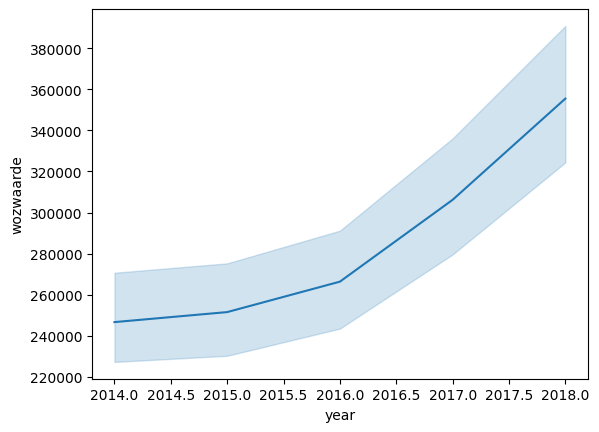

In [14]:
sns.lineplot(x="year", y="wozwaarde", data = df_merged)

<Axes: xlabel='year', ylabel='wozwaarde'>

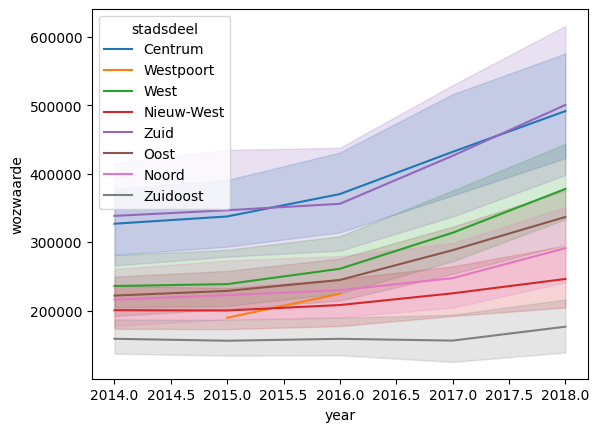

In [15]:
sns.lineplot(x="year", y="wozwaarde", hue = "stadsdeel", data = df_merged)

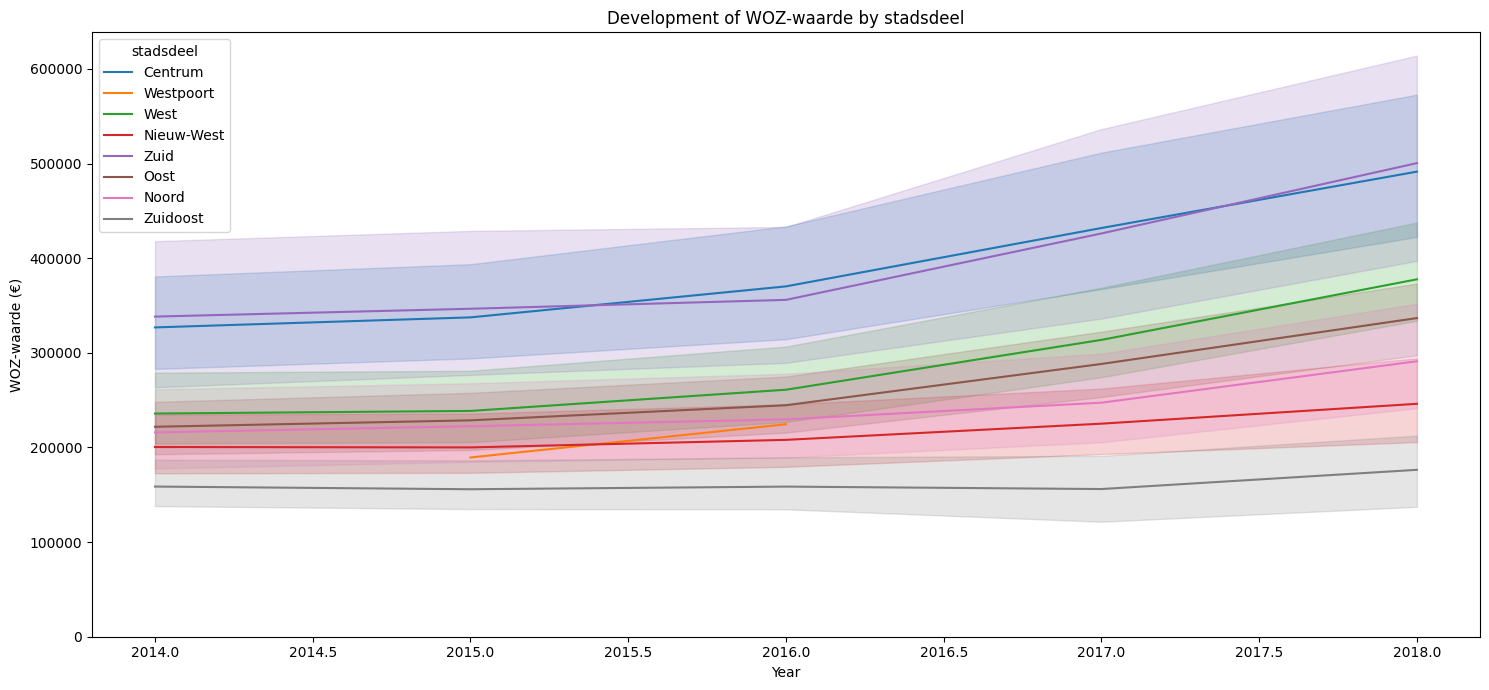

In [16]:
# Or a bit nicer

plt.figure(figsize=(15, 7))
sns.lineplot(data=df_merged, x="year", y="wozwaarde", hue="stadsdeel")
plt.ylim(bottom=0)
plt.title("Development of WOZ-waarde by stadsdeel")
plt.xlabel("Year")
plt.ylabel("WOZ-waarde (€)")
plt.tight_layout()
plt.show()


#### Let's zoom in!
Oost only?

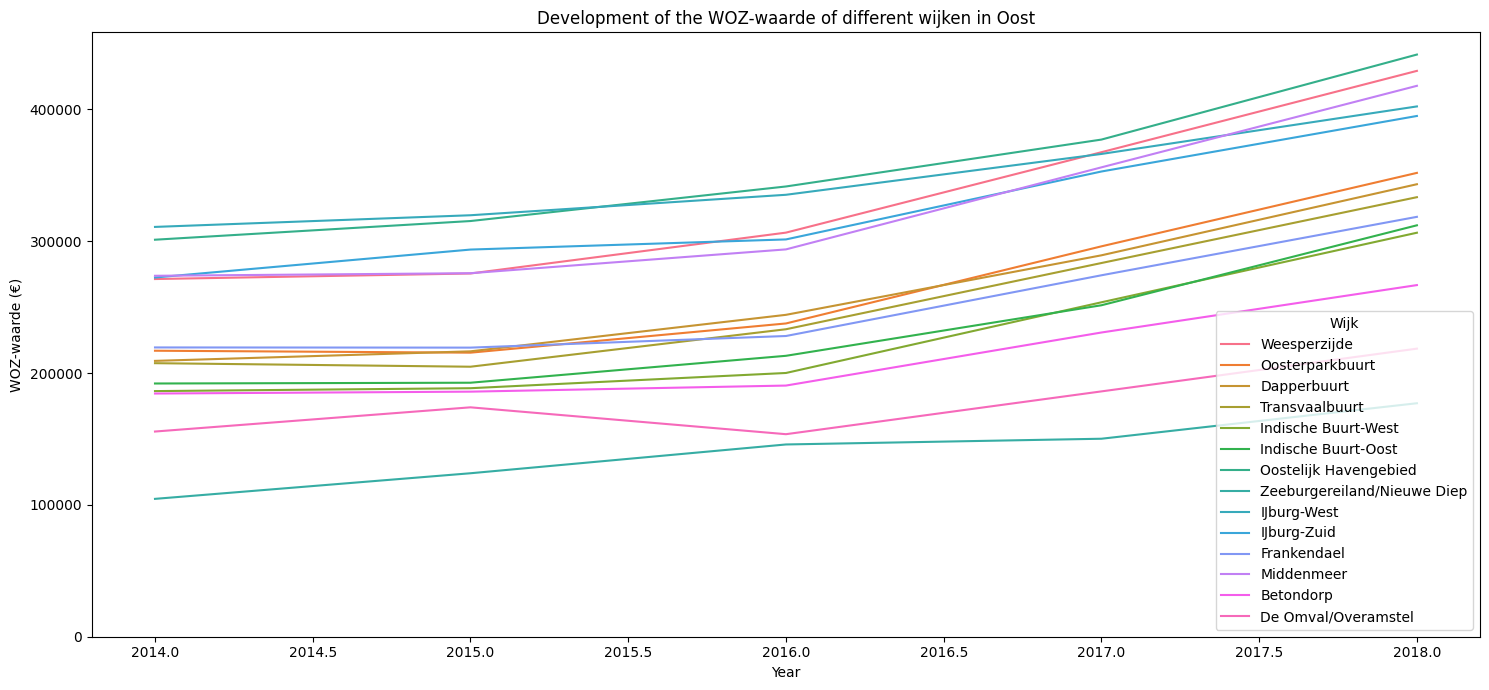

In [17]:
# Filter once and store
oost_data = df_merged[df_merged["stadsdeel"] == "Oost"]

# Plot
plt.figure(figsize=(15, 7))
sns.lineplot(data=oost_data, x="year", y="wozwaarde", hue="wijk")
plt.ylim(bottom=0)
plt.title("Development of the WOZ-waarde of different wijken in Oost")
plt.xlabel("Year")
plt.ylabel("WOZ-waarde (€)")
plt.legend(title="Wijk")
plt.tight_layout()
plt.show()

### Is there a relationship between the population and the prices?

Not really maybe?

In [18]:
df_merged[['wozwaarde','populatie']].corr()

,wozwaarde,populatie
wozwaarde,1.000000,0.066708
populatie,0.066708,1.000000


In [19]:
df_merged

,wijk,code,stadsdeel,year,wozwaarde,populatie
0,Burgwallen-Oude Zijde,A00,Centrum,2014,263417.0,NaN
1,Burgwallen-Nieuwe Zijde,A01,Centrum,2014,267895.0,NaN
2,Grachtengordel-West,A02,Centrum,2014,490251.0,NaN
3,Grachtengordel-Zuid,A03,Centrum,2014,469946.0,NaN
4,Nieuwmarkt/Lastage,A04,Centrum,2014,295239.0,NaN
...,...,...,...,...,...,...
485,"Bijlmer-Oost (E,G,K)",T94,Zuidoost,2018,182291.0,87999.0
486,Nellestein,T95,Zuidoost,2018,170441.0,87999.0
487,Holendrecht/Reigersbos,T96,Zuidoost,2018,181189.0,87999.0
488,Gein,T97,Zuidoost,2018,199542.0,87999.0
